In [2]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

In [48]:
def plot_cross_section(filename, hist_path, xlabel, ylabel, bin_edges_labels,
                       figsize=(5, 4), output_name=None):
    """
    Plot cross-section data from a ROOT file with error bars.

    Parameters
    ----------
    filename : str
        Path to the ROOT file
    hist_path : str
        Path to the histogram within the ROOT file (e.g., "gundam/calcXsec/throws/histograms/TrueDeltaPT_XS_TH1D;1")
    xlabel : str
        Label for the x-axis (use raw string with LaTeX, e.g., r'True $\delta_{pT}$ [GeV]')
    ylabel : str
        Label for the y-axis (use raw string with LaTeX, e.g., r'$\frac{d\sigma}{dp_T}$ $\left[\frac{cm^2}{GeV/c^2}\right]$')
    bin_edges_labels : list
        List of bin edge values to display on x-axis (e.g., [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    figsize : tuple, optional
        Figure size (width, height). Default is (5, 4)
    output_name : str, optional
        Output filename for saving the plot. If None, uses the histogram name. Default is None

    Returns
    -------
    fig, ax : matplotlib figure and axis objects
    """
    # Open the ROOT file
    file = uproot.open(filename)

    # Navigate to the histogram
    hist = file[hist_path]

    # Extract bin values and errors
    bin_values = hist.values()
    bin_errors = hist.errors()

    # Calculate bin centers from provided bin edges
    bin_edges_array = np.array(bin_edges_labels)
    bin_centers = (bin_edges_array[:-1] + bin_edges_array[1:]) / 2
    bin_widths = np.diff(bin_edges_array)

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot using errorbar
    ax.errorbar(bin_centers,
                bin_values,
                xerr=bin_widths / 2,  # Half bin width for symmetric error bars
                yerr=bin_errors,
                fmt='o',
                markersize=7,
                markerfacecolor='black',
                markeredgecolor='black',
                color='black',
                capsize=4,
                capthick=1.5,
                elinewidth=1.5,
                linewidth=2)

    # Set axis labels
    ax.set_xlabel(xlabel, fontsize=12, weight='bold')
    ax.set_ylabel(ylabel, fontsize=12, weight='bold')

    # Set axis limits
    ax.set_xlim(bin_edges_array[0], bin_edges_array[-1])
    y_min = 0
    y_max = np.max(bin_values + bin_errors) * 1.2
    ax.set_ylim(y_min, y_max)

    # Set x-axis ticks at bin edges
    ax.set_xticks(bin_edges_array)
    ax.set_xticklabels([f'{x:.1f}' for x in bin_edges_array], fontsize=10)

    # Set tick parameters
    ax.tick_params(axis='both', which='major',
                   labelsize=12,
                   size=8,
                   width=2,
                   direction='in')

    # Enable minor ticks
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor',
                   size=4,
                   width=1,
                   direction='in')
    ax.tick_params(axis='x', which='minor',
                   size=4,
                   width=1,
                   direction='in')

    # Format y-axis with scientific notation
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(-39, -39))

    # Grid
    ax.grid(True, alpha=0.3)

    # Tight layout
    plt.tight_layout()

    # Save the plot
    if output_name is None:
        output_name = f"{hist.name}_matplotlib.png"
    plt.savefig(output_name, dpi=300, bbox_inches='tight')

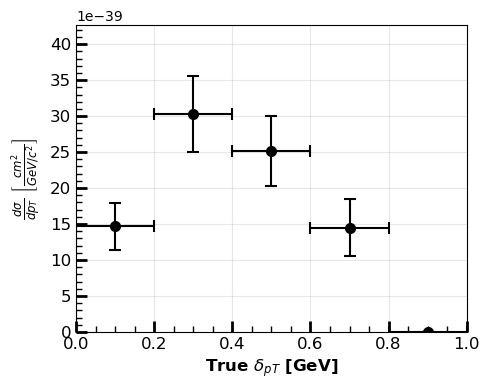

In [50]:
# For TrueDeltaPT
plot_cross_section(
    '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/exampleXSec.root',
    "calcXsec/histograms/TrueDeltaPT_XS_TH1D;1",
    r'True $\delta_{pT}$ [GeV]',
    r'$\frac{d\sigma}{dp_T}$ $\left[\frac{cm^2}{GeV/c^2}\right]$',
    [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
)